# Supplemental Fig. S3: SHARE-seq mouse skin

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/figS3_shareseq.ipynb)

Paired RNA + ATAC from late-anagen mouse skin (Ma et al. 2020): 22 cell types across epidermal, hair-follicle, dermal, and immune lineages, with sparser ATAC than 10x Multiome. Settings follow the archived notebook `UniVI_manuscript_GR-Supple_____mouse_skin_SHARE-seq_integration.ipynb`; preprocessing uses UniVI's fitted preprocessors, so results will be close to, not identical with, the published ones.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1" "pandas==2.2.3"

In [2]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import (compute_modality_mixing, cross_modal_predict, encode_adata, evaluate_alignment,
                              pearson_corr_per_feature)
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 5000   # archived notebook: 5000 with early stopping (patience 200)
N_HVG = 5000
N_LSI = 101       # fit 101 components, drop the first (depth-correlated) one

## Data, split, preprocessing

The hosted files are after quality control, ENCODE blacklist filtering, and removal of the ambiguous "Mix" label, with the 80/10/10 stratified split used in the article in `obs["split"]`. Mitochondrial, ribosomal, `Rik`, and pseudogene families are excluded from HVG selection; peaks open in 0.25–80% of training cells are kept; TF-IDF uses the Signac convention.

In [4]:
data = uds.load("shareseq_mouse_skin")
rna, atac = data["rna"], data["atac"]
if "split" in rna.obs:
    splits = {k: np.flatnonzero(rna.obs["split"].to_numpy() == k) for k in ("train", "val", "test")}
else:
    splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=42)
print({k: len(v) for k, v in splits.items()})

pattern = re.compile(r"^(mt-|Rps|Rpl|Mrps|Mrpl)|Rik$|-ps\d*$")
excluded = [g for g in rna.var_names if pattern.search(g)]
rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True, exclude_genes=excluded).fit(rna[splits["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True, method="signac",
                             min_fraction=0.0025, max_fraction=0.80).fit(atac[splits["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": atac_prep.transform(atac[i])} for k, i in splits.items()}

shareseq_mouse_skin_rna.h5ad: 100%|██████████| 46.6M/46.6M [00:24<00:00, 1.94MB/s]
shareseq_mouse_skin_atac.h5ad: 100%|██████████| 246M/246M [02:57<00:00, 1.39MB/s] 


{'train': 21845, 'val': 3112, 'test': 6263}


In [5]:
cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=6.35, encoder_dropout=0.10, decoder_dropout=0.0,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[
        ModalityConfig("rna", parts["train"]["rna"].n_vars, [1024, 512, 256, 128], [128, 256, 512, 1024], likelihood="gaussian"),
        ModalityConfig("atac", parts["train"]["atac"].n_vars, [256, 128, 64], [64, 128, 256], likelihood="gaussian"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(
    model, make_loader(parts["train"], batch_size=128, shuffle=True, drop_last=True),
    make_loader(parts["val"], batch_size=1024),
    TrainingConfig(n_epochs=N_EPOCHS, batch_size=128, lr=1e-3, weight_decay=1e-4, device=device,
                   early_stopping=True, patience=200, best_epoch_warmup=110, log_every=100),
).fit();

[2026-09-21 16:17:27,608] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 16:17:27,609] [UniVITrainer] [INFO]   n_epochs: 5000
[2026-09-21 16:17:27,610] [UniVITrainer] [INFO]   batch_size: 128
[2026-09-21 16:17:27,611] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-21 16:17:27,614] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-21 16:17:27,614] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 16:17:27,615] [UniVITrainer] [INFO]   log_every: 100
[2026-09-21 16:17:27,616] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 16:17:27,617] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 16:17:27,617] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 16:17:27,618] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 16:17:27,619] [UniVITrainer] [INFO]   patience: 200
[2026-09-21 16:17:27,619] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 16:17:27,620] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/5000 [00:00<?, ?it/s][2026-09-21 16:17:33,091] 

## Held-out test cells

In [6]:
test = parts["test"]
z_rna = encode_adata(model, test["rna"], modality="rna", device=device, latent="modality_mean")
z_atac = encode_adata(model, test["atac"], modality="atac", device=device, latent="modality_mean")
lab = test["rna"].obs["cell_type"].astype(str).to_numpy()
m = evaluate_alignment(Z1=z_rna, Z2=z_atac, labels_source=lab, labels_target=lab, recall_ks=(10,))
bi = m.get("bidirectional_transfer", {})
pd.Series({"FOSCTTM": m["foscttm_mean"], "Recall@10": m["recall_at_k"]["10"]["mean"],
           "modality mixing (k=30)": compute_modality_mixing(np.vstack([z_rna, z_atac]), np.repeat(["rna", "atac"], len(z_rna)), k=30),
           "label transfer acc (RNA to ATAC)": m["label_transfer_acc"],
           "macro-F1, worse direction": m["worst_direction_macro_f1"]}).round(3)

FOSCTTM                             0.117
Recall@10                           0.072
modality mixing (k=30)              0.157
label transfer acc (RNA to ATAC)    0.730
macro-F1, worse direction           0.609
dtype: float64

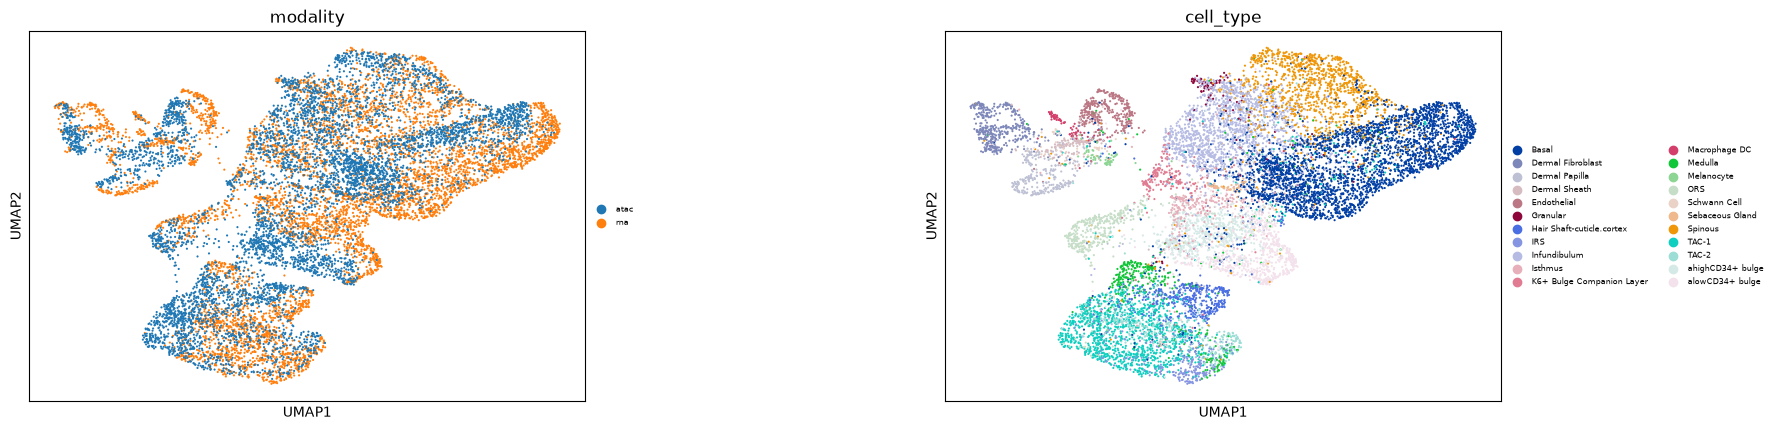

In [7]:
joint = stack_embeddings(model, [("test", "rna", test["rna"]), ("test", "atac", test["atac"])], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=["modality", "cell_type"], wspace=0.5, legend_fontsize=6)

## Cross-modal reconstruction, per feature (Supplemental Fig. S3C–D)

RNA to ATAC is evaluated in the LSI representation; ATAC to RNA on z-scored log-normalized expression.

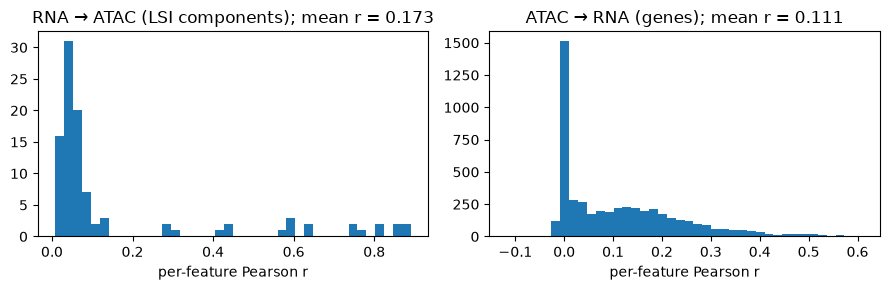

In [8]:
r_atac = pearson_corr_per_feature(np.asarray(test["atac"].X),
                                  cross_modal_predict(model, test["rna"], src_mod="rna", tgt_mod="atac", device=device))
r_rna = pearson_corr_per_feature(np.asarray(test["rna"].X),
                                 cross_modal_predict(model, test["atac"], src_mod="atac", tgt_mod="rna", device=device))
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, r, title in zip(axes, [r_atac, r_rna], ["RNA → ATAC (LSI components)", "ATAC → RNA (genes)"]):
    ax.hist(r[np.isfinite(r)], bins=40)
    ax.set(title=f"{title}; mean r = {np.nanmean(r):.3f}", xlabel="per-feature Pearson r")
plt.tight_layout()
plt.show()